In [1]:
# ============================================================
# CELL 1: IMPORT REQUIRED LIBRARIES
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    roc_curve
)

from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE

import warnings
warnings.filterwarnings("ignore")

In [2]:
# ============================================================
# CELL 2: LOAD THE DATASET
# ============================================================

df = pd.read_csv("health_lifestyle_dataset.csv", engine="python", on_bad_lines="skip")

print("Dataset loaded successfully.")
print("Dataset shape:", df.shape)
display(df.head())

Dataset loaded successfully.
Dataset shape: (117259, 16)


,id,age,gender,bmi,daily_steps,sleep_hours,water_intake_l,calories_consumed,smoker,alcohol,resting_hr,systolic_bp,diastolic_bp,cholesterol,family_history,disease_risk
0,1,56,Male,20.5,4198,3.9,3.4,1602,0,0,97,161,111,240,0,0
1,2,69,Female,33.3,14359,9.0,4.7,2346,0,1,68,116,65,207,0,0
2,3,46,Male,31.6,1817,6.6,4.2,1643,0,1,90,123,99,296,0,0
3,4,32,Female,38.2,15772,3.6,2.0,2460,0,0,71,165,95,175,0,0
4,5,60,Female,33.6,6037,3.8,4.0,3756,0,1,98,139,61,294,0,0


In [3]:
# ============================================================
# CELL 3: INITIAL DATA INSPECTION
# ============================================================

print("Dataset information:")
print(df.info())

print("\nMissing values in each column:")
print(df.isnull().sum())

print("\nNumber of duplicate rows:", df.duplicated().sum())

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 117259 entries, 0 to 117258
Data columns (total 16 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   id                 117259 non-null  int64  
 1   age                117259 non-null  int64  
 2   gender             117259 non-null  object 
 3   bmi                117259 non-null  float64
 4   daily_steps        117259 non-null  int64  
 5   sleep_hours        117259 non-null  float64
 6   water_intake_l     117259 non-null  float64
 7   calories_consumed  117259 non-null  int64  
 8   smoker             117259 non-null  int64  
 9   alcohol            117259 non-null  int64  
 10  resting_hr         117259 non-null  int64  
 11  systolic_bp        117259 non-null  int64  
 12  diastolic_bp       117259 non-null  int64  
 13  cholesterol        117259 non-null  int64  
 14  family_history     117259 non-null  int64  
 15  disease_risk       117259 non-

In [4]:
# ============================================================
# CELL 4: BASIC PREPROCESSING
# ============================================================

# Clean the gender column
df["gender"] = df["gender"].astype(str).str.strip().str.lower()
df["gender"] = df["gender"].replace({"m": "male", "f": "female"})

# Convert binary-type columns into integer format
for col in ["smoker", "alcohol", "family_history", "disease_risk"]:
    df[col] = pd.to_numeric(df[col], errors="coerce").fillna(0).astype(int)

print("Gender value counts after cleaning:")
print(df["gender"].value_counts())

display(df.head())

Gender value counts after cleaning:
gender
male      58788
female    58471
Name: count, dtype: int64


,id,age,gender,bmi,daily_steps,sleep_hours,water_intake_l,calories_consumed,smoker,alcohol,resting_hr,systolic_bp,diastolic_bp,cholesterol,family_history,disease_risk
0,1,56,male,20.5,4198,3.9,3.4,1602,0,0,97,161,111,240,0,0
1,2,69,female,33.3,14359,9.0,4.7,2346,0,1,68,116,65,207,0,0
2,3,46,male,31.6,1817,6.6,4.2,1643,0,1,90,123,99,296,0,0
3,4,32,female,38.2,15772,3.6,2.0,2460,0,0,71,165,95,175,0,0
4,5,60,female,33.6,6037,3.8,4.0,3756,0,1,98,139,61,294,0,0


In [5]:
# ============================================================
# CELL 5: CREATE THE NEW TARGET VARIABLE
# LIFESTYLE_RISK = 1 if any of the following are true:
# smoker = 1, alcohol = 1, bmi >= 30, daily_steps < 5000
# Otherwise, LIFESTYLE_RISK = 0
# ============================================================

df["LIFESTYLE_RISK"] = np.where(
    (df["smoker"] == 1) |
    (df["alcohol"] == 1) |
    (df["bmi"] >= 30) |
    (df["daily_steps"] < 5000),
    1,
    0
)

print("Target distribution of LIFESTYLE_RISK:")
print(df["LIFESTYLE_RISK"].value_counts())

Target distribution of LIFESTYLE_RISK:
LIFESTYLE_RISK
1    89263
0    27996
Name: count, dtype: int64


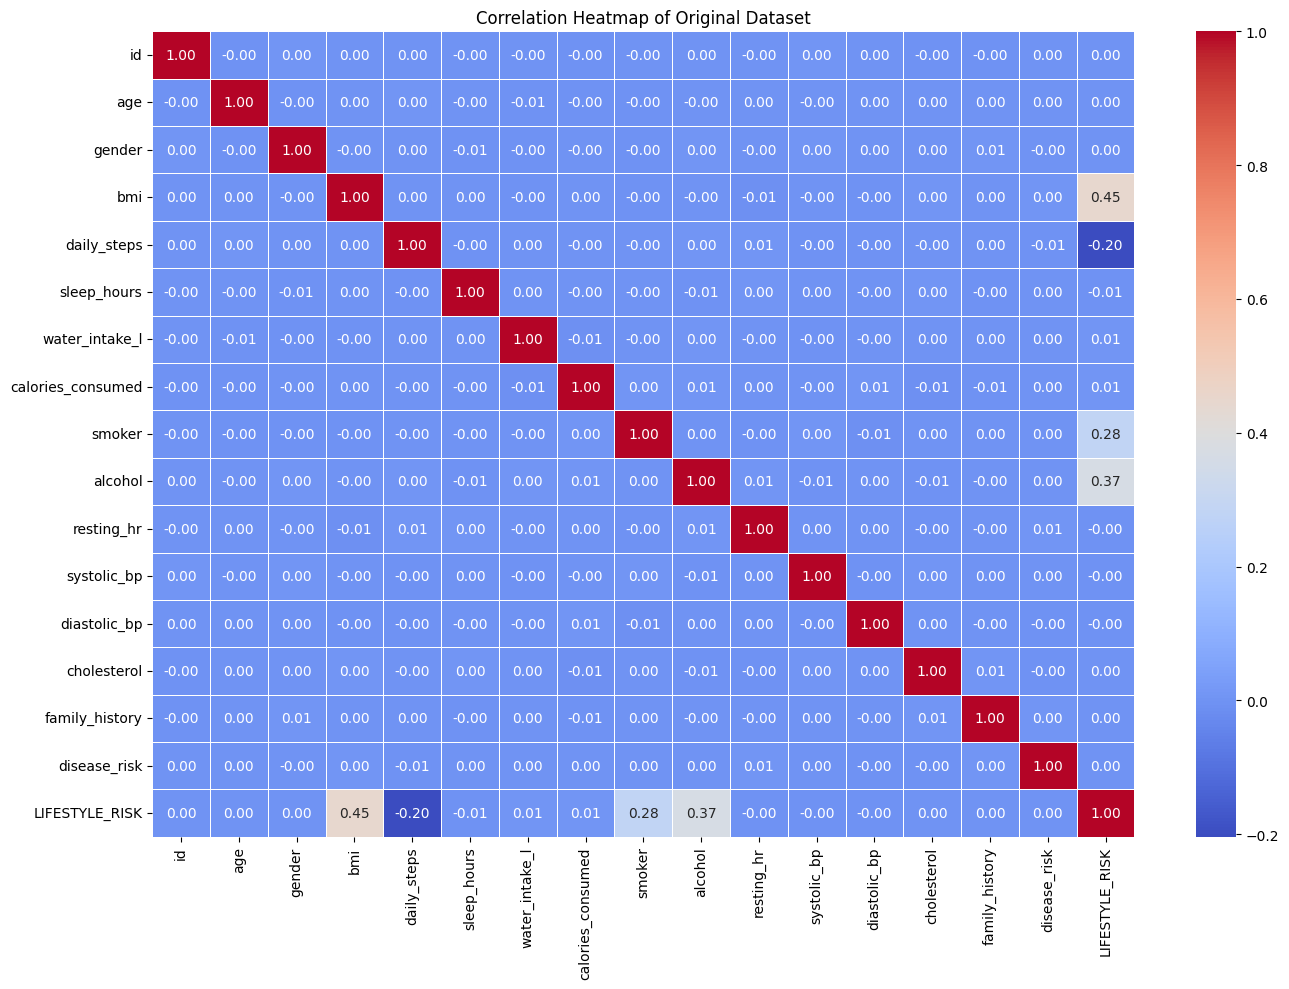

In [6]:
# ============================================================
# CELL 6: CORRELATION HEATMAP
# This helps to understand how the variables relate to each
# other and to the target variable.
# ============================================================

heatmap_df = df.copy()
heatmap_df["gender"] = heatmap_df["gender"].map({"male": 1, "female": 0})

plt.figure(figsize=(14, 10))
sns.heatmap(
    heatmap_df.corr(numeric_only=True),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5
)
plt.title("Correlation Heatmap of Original Dataset")
plt.tight_layout()
plt.show()

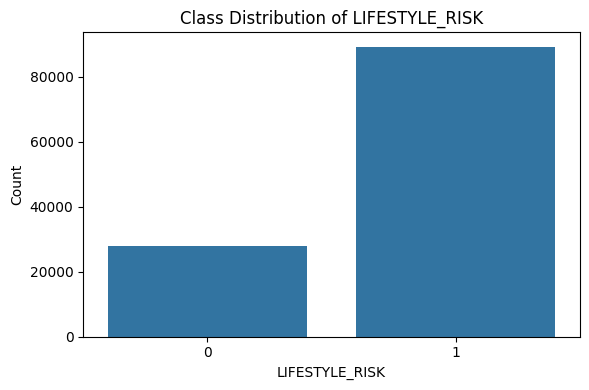

LIFESTYLE_RISK
1    89263
0    27996
Name: count, dtype: int64


In [7]:
# ============================================================
# CELL 7: PLOT TARGET CLASS DISTRIBUTION
# ============================================================

plt.figure(figsize=(6, 4))
sns.countplot(x="LIFESTYLE_RISK", data=df)
plt.title("Class Distribution of LIFESTYLE_RISK")
plt.xlabel("LIFESTYLE_RISK")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

print(df["LIFESTYLE_RISK"].value_counts())

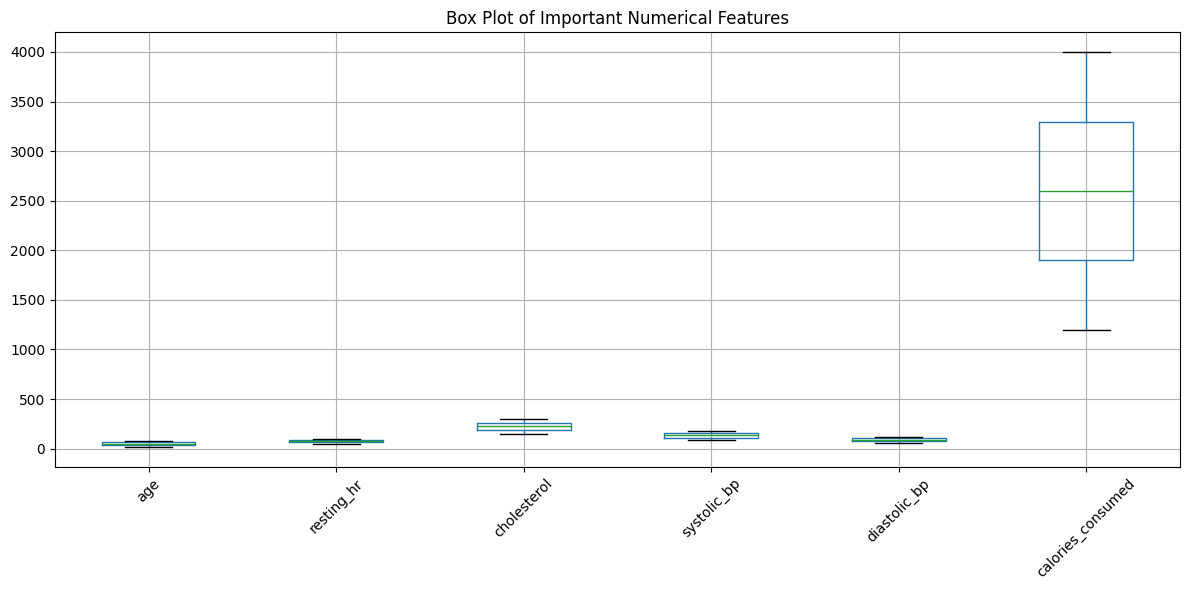

In [8]:
# ============================================================
# CELL 8: BOXPLOTS OF IMPORTANT NUMERICAL FEATURES
# ============================================================

num_cols = ["age", "resting_hr", "cholesterol", "systolic_bp", "diastolic_bp", "calories_consumed"]

plt.figure(figsize=(12, 6))
df[num_cols].boxplot(rot=45)
plt.title("Box Plot of Important Numerical Features")
plt.tight_layout()
plt.show()

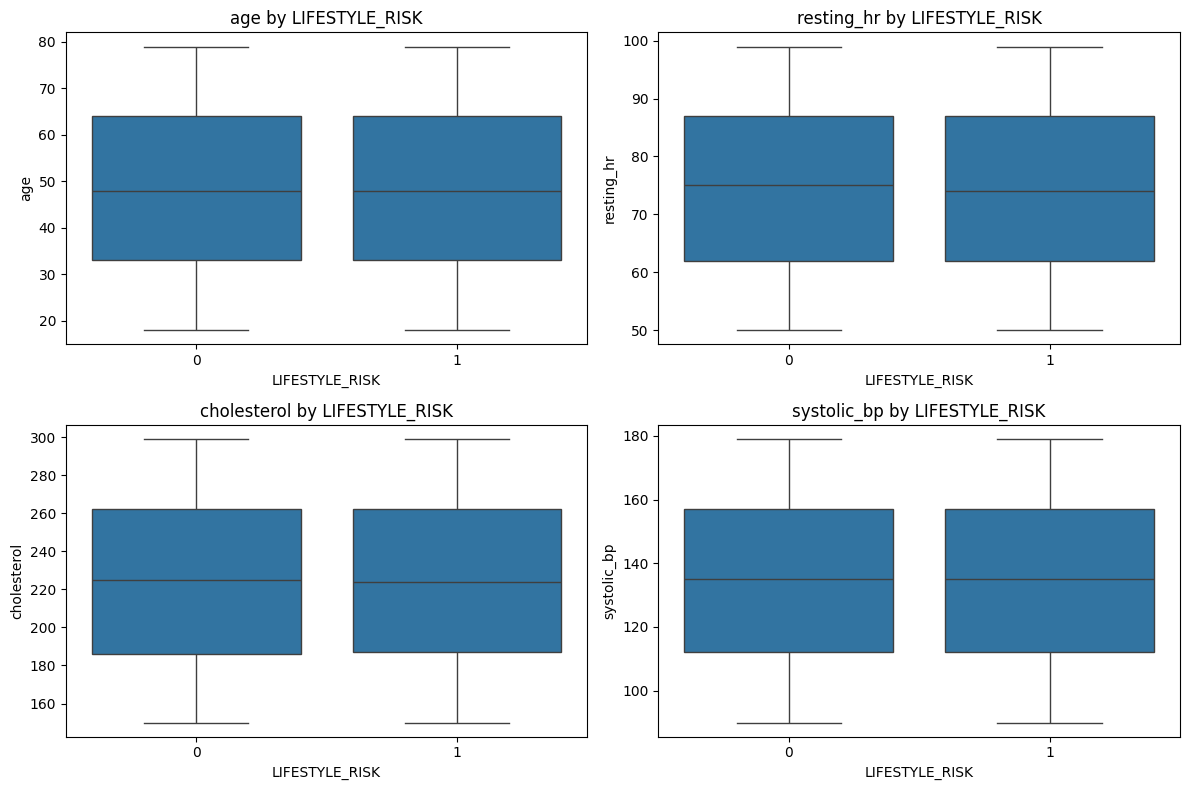

In [9]:
# ============================================================
# CELL 9: FEATURE DISTRIBUTIONS BY TARGET CLASS
# ============================================================

plot_cols = ["age", "resting_hr", "cholesterol", "systolic_bp"]

plt.figure(figsize=(12, 8))
for i, col in enumerate(plot_cols, 1):
    plt.subplot(2, 2, i)
    sns.boxplot(x="LIFESTYLE_RISK", y=col, data=df)
    plt.title(f"{col} by LIFESTYLE_RISK")

plt.tight_layout()
plt.show()

In [10]:
# ============================================================
# CELL 10: DROP NON-MODELLING AND LEAKAGE COLUMNS
# Remove:
# - id
# - old target disease_risk
# - variables used to create LIFESTYLE_RISK:
#   smoker, alcohol, bmi, daily_steps
# ============================================================

df_model = df.drop(
    columns=["id", "disease_risk", "smoker", "alcohol", "bmi", "daily_steps"],
    errors="ignore"
)

print("Columns used for modelling:")
print(df_model.columns.tolist())

display(df_model.head())

Columns used for modelling:
['age', 'gender', 'sleep_hours', 'water_intake_l', 'calories_consumed', 'resting_hr', 'systolic_bp', 'diastolic_bp', 'cholesterol', 'family_history', 'LIFESTYLE_RISK']


,age,gender,sleep_hours,water_intake_l,calories_consumed,resting_hr,systolic_bp,diastolic_bp,cholesterol,family_history,LIFESTYLE_RISK
0,56,male,3.9,3.4,1602,97,161,111,240,0,1
1,69,female,9.0,4.7,2346,68,116,65,207,0,1
2,46,male,6.6,4.2,1643,90,123,99,296,0,1
3,32,female,3.6,2.0,2460,71,165,95,175,0,1
4,60,female,3.8,4.0,3756,98,139,61,294,0,1


In [11]:
# ============================================================
# CELL 11: ONE-HOT ENCODING
# Convert categorical variables into numerical form
# ============================================================

df_model = pd.get_dummies(df_model, drop_first=True)

# Convert boolean columns to integer if any exist
bool_cols = df_model.select_dtypes(include="bool").columns
df_model[bool_cols] = df_model[bool_cols].astype(int)

print("Encoded dataset shape:", df_model.shape)
display(df_model.head())

Encoded dataset shape: (117259, 11)


,age,sleep_hours,water_intake_l,calories_consumed,resting_hr,systolic_bp,diastolic_bp,cholesterol,family_history,LIFESTYLE_RISK,gender_male
0,56,3.9,3.4,1602,97,161,111,240,0,1,1
1,69,9.0,4.7,2346,68,116,65,207,0,1,0
2,46,6.6,4.2,1643,90,123,99,296,0,1,1
3,32,3.6,2.0,2460,71,165,95,175,0,1,0
4,60,3.8,4.0,3756,98,139,61,294,0,1,0


In [12]:
# ============================================================
# CELL 12: DEFINE FEATURES AND TARGET
# ============================================================

X = df_model.drop("LIFESTYLE_RISK", axis=1)
y = df_model["LIFESTYLE_RISK"]

print("Feature matrix shape:", X.shape)
print("Target vector shape:", y.shape)

print("\nTarget distribution:")
print(y.value_counts())

Feature matrix shape: (117259, 10)
Target vector shape: (117259,)

Target distribution:
LIFESTYLE_RISK
1    89263
0    27996
Name: count, dtype: int64


In [13]:
# ============================================================
# CELL 13: SPLIT DATA INTO TRAINING AND TEST SETS
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print("Training set shape:", X_train.shape)
print("Testing set shape :", X_test.shape)

print("\nTraining target distribution:")
print(y_train.value_counts())

print("\nTesting target distribution:")
print(y_test.value_counts())

Training set shape: (93807, 10)
Testing set shape : (23452, 10)

Training target distribution:
LIFESTYLE_RISK
1    71410
0    22397
Name: count, dtype: int64

Testing target distribution:
LIFESTYLE_RISK
1    17853
0     5599
Name: count, dtype: int64


In [14]:
# ============================================================
# CELL 14: SCALE FEATURES
# ============================================================

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Feature scaling completed.")

Feature scaling completed.


In [15]:
# ============================================================
# CELL 15: MODEL EVALUATION FUNCTION
# This function prints metrics and plots confusion matrix
# and ROC curve for any model
# ============================================================

def evaluate_model(model, X_test_data, y_test_data, model_name):
    y_pred = model.predict(X_test_data)
    y_prob = model.predict_proba(X_test_data)[:, 1]

    acc = accuracy_score(y_test_data, y_pred)
    auc = roc_auc_score(y_test_data, y_prob)
    cm = confusion_matrix(y_test_data, y_pred)

    print(f"\n{model_name}")
    print("Accuracy:", round(acc, 4))
    print("ROC-AUC :", round(auc, 4))
    print("\nClassification Report:")
    print(classification_report(y_test_data, y_pred))
    print("Confusion Matrix:")
    print(cm)

    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(f"{model_name} - Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.tight_layout()
    plt.show()

    fpr, tpr, _ = roc_curve(y_test_data, y_prob)
    plt.figure(figsize=(5, 4))
    plt.plot(fpr, tpr, label=f"AUC = {auc:.4f}")
    plt.plot([0, 1], [0, 1], linestyle="--")
    plt.title(f"{model_name} - ROC Curve")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.legend()
    plt.tight_layout()
    plt.show()

    return acc, auc


Random Forest Before SMOTE
Accuracy: 0.8187
ROC-AUC : 0.7116

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.24      0.39      5599
           1       0.81      1.00      0.89     17853

    accuracy                           0.82     23452
   macro avg       0.90      0.62      0.64     23452
weighted avg       0.85      0.82      0.77     23452

Confusion Matrix:
[[ 1350  4249]
 [    3 17850]]


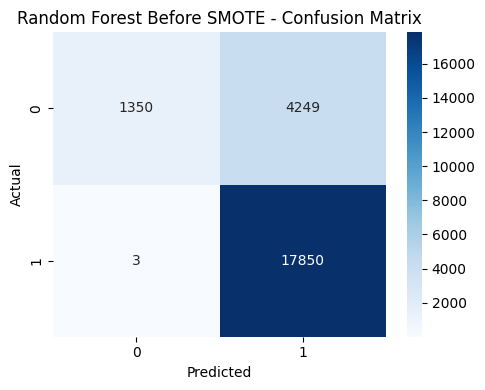

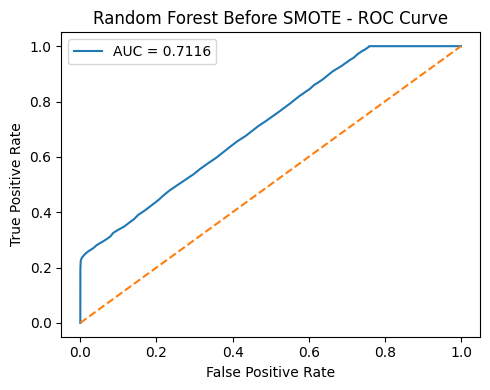

In [16]:
# ============================================================
# CELL 16: RANDOM FOREST BEFORE SMOTE
# ============================================================

rf_before = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

rf_before.fit(X_train_scaled, y_train)

rf_before_acc, rf_before_auc = evaluate_model(
    rf_before, X_test_scaled, y_test, "Random Forest Before SMOTE"
)

In [17]:
# ============================================================
# CELL 17: APPLY SMOTE TO TRAINING DATA
# ============================================================

print("Class distribution before SMOTE:")
print(y_train.value_counts())

smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)

print("\nClass distribution after SMOTE:")
print(pd.Series(y_train_smote).value_counts())

Class distribution before SMOTE:
LIFESTYLE_RISK
1    71410
0    22397
Name: count, dtype: int64

Class distribution after SMOTE:
LIFESTYLE_RISK
0    71410
1    71410
Name: count, dtype: int64



Random Forest After SMOTE
Accuracy: 0.8152
ROC-AUC : 0.7083

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.25      0.39      5599
           1       0.81      0.99      0.89     17853

    accuracy                           0.82     23452
   macro avg       0.87      0.62      0.64     23452
weighted avg       0.84      0.82      0.77     23452

Confusion Matrix:
[[ 1379  4220]
 [  114 17739]]


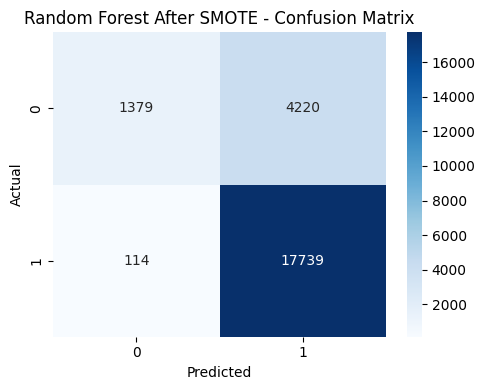

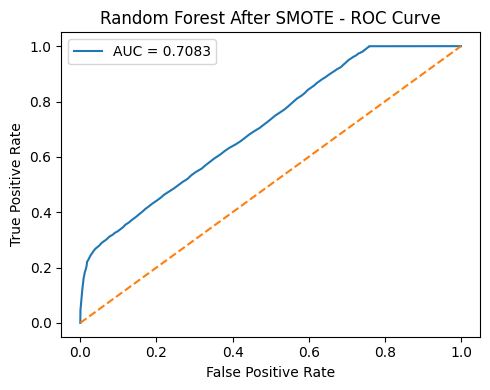

In [18]:
# ============================================================
# CELL 18: RANDOM FOREST AFTER SMOTE
# ============================================================

rf_after = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

rf_after.fit(X_train_smote, y_train_smote)

rf_after_acc, rf_after_auc = evaluate_model(
    rf_after, X_test_scaled, y_test, "Random Forest After SMOTE"
)

In [19]:
# ============================================================
# CELL 19: COMPARE RANDOM FOREST BEFORE AND AFTER SMOTE
# ============================================================

smote_comparison = pd.DataFrame({
    "Model": ["RF Before SMOTE", "RF After SMOTE"],
    "Accuracy": [rf_before_acc, rf_after_acc],
    "ROC-AUC": [rf_before_auc, rf_after_auc]
})

display(smote_comparison)

,Model,Accuracy,ROC-AUC
0,RF Before SMOTE,0.818694,0.711563
1,RF After SMOTE,0.815197,0.708298



Baseline XGBoost
Accuracy: 0.7583
ROC-AUC : 0.5141

Classification Report:
              precision    recall  f1-score   support

           0       0.29      0.01      0.02      5599
           1       0.76      0.99      0.86     17853

    accuracy                           0.76     23452
   macro avg       0.52      0.50      0.44     23452
weighted avg       0.65      0.76      0.66     23452

Confusion Matrix:
[[   46  5553]
 [  115 17738]]


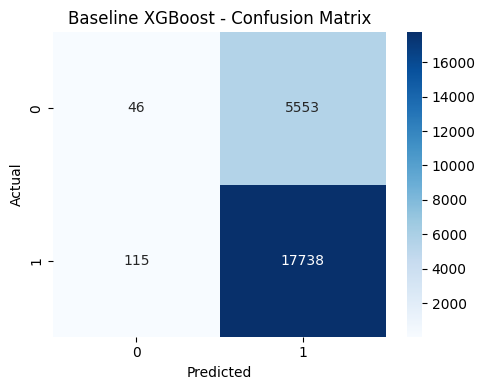

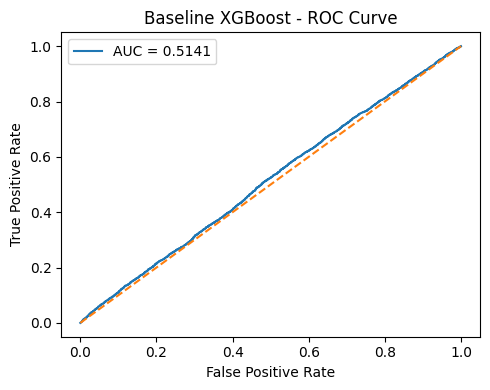

In [20]:
# ============================================================
# CELL 20: BASELINE XGBOOST MODEL
# ============================================================

xgb_model = XGBClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=1.0,
    random_state=42,
    n_jobs=-1,
    eval_metric="logloss"
)

xgb_model.fit(X_train_smote, y_train_smote)

xgb_acc, xgb_auc = evaluate_model(
    xgb_model, X_test_scaled, y_test, "Baseline XGBoost"
)

In [21]:
# ============================================================
# CELL 21: HYPERPARAMETER TUNING FOR XGBOOST
# ============================================================

xgb_param_grid = {
    "n_estimators": [100, 300, 500],
    "learning_rate": [0.01, 0.05, 0.1],
    "max_depth": [3, 5, 7, 9],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.7, 0.8, 0.9, 1.0],
    "reg_lambda": [1, 5, 10],
    "min_child_weight": [1, 3, 5]
}

xgb_search = RandomizedSearchCV(
    estimator=XGBClassifier(
        random_state=42,
        n_jobs=-1,
        eval_metric="logloss"
    ),
    param_distributions=xgb_param_grid,
    n_iter=20,
    cv=5,
    scoring="roc_auc",
    verbose=1,
    random_state=42,
    n_jobs=-1
)

xgb_search.fit(X_train_smote, y_train_smote)

print("Best Parameters:", xgb_search.best_params_)
print("Best CV ROC-AUC:", xgb_search.best_score_)

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best Parameters: {'subsample': 0.8, 'reg_lambda': 10, 'n_estimators': 500, 'min_child_weight': 5, 'max_depth': 9, 'learning_rate': 0.1, 'colsample_bytree': 0.8}
Best CV ROC-AUC: 0.8807750571093029



Tuned XGBoost
Accuracy: 0.7654
ROC-AUC : 0.6076

Classification Report:
              precision    recall  f1-score   support

           0       0.60      0.05      0.09      5599
           1       0.77      0.99      0.87     17853

    accuracy                           0.77     23452
   macro avg       0.69      0.52      0.48     23452
weighted avg       0.73      0.77      0.68     23452

Confusion Matrix:
[[  277  5322]
 [  181 17672]]


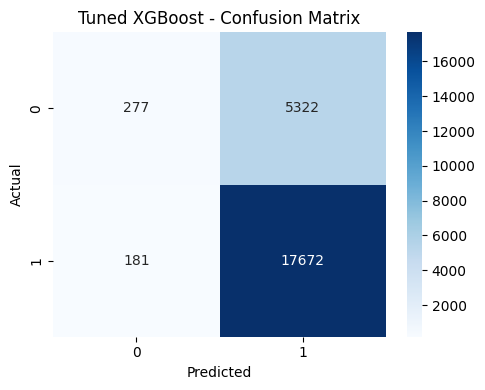

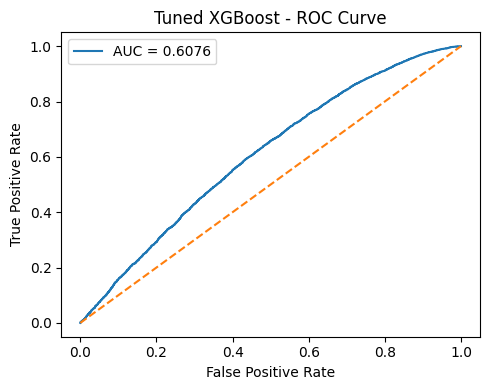

In [22]:
# ============================================================
# CELL 22: EVALUATE TUNED XGBOOST
# ============================================================

xgb_best = xgb_search.best_estimator_

xgb_best_acc, xgb_best_auc = evaluate_model(
    xgb_best, X_test_scaled, y_test, "Tuned XGBoost"
)


Baseline ANN
Accuracy: 0.5839
ROC-AUC : 0.536

Classification Report:
              precision    recall  f1-score   support

           0       0.26      0.41      0.32      5599
           1       0.78      0.64      0.70     17853

    accuracy                           0.58     23452
   macro avg       0.52      0.53      0.51     23452
weighted avg       0.65      0.58      0.61     23452

Confusion Matrix:
[[ 2309  3290]
 [ 6469 11384]]


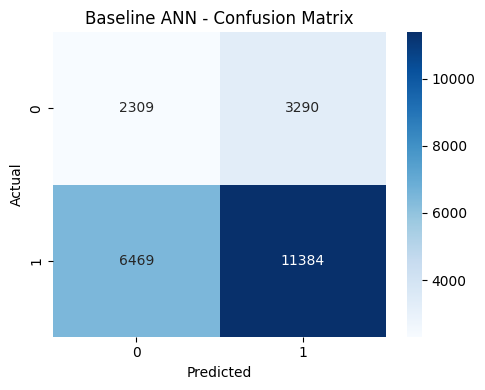

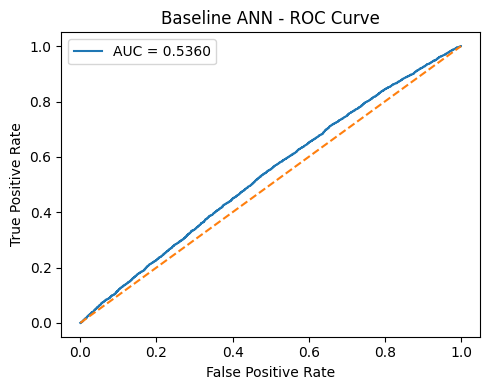

In [23]:
# ============================================================
# CELL 23: BASELINE ARTIFICIAL NEURAL NETWORK
# ============================================================

ann_model = MLPClassifier(
    hidden_layer_sizes=(128, 64),
    activation="relu",
    solver="adam",
    alpha=0.0001,
    learning_rate_init=0.001,
    max_iter=50,
    batch_size=256,
    random_state=42
)

ann_model.fit(X_train_smote, y_train_smote)

ann_acc, ann_auc = evaluate_model(
    ann_model, X_test_scaled, y_test, "Baseline ANN"
)

In [24]:
# ============================================================
# CELL 24: HYPERPARAMETER TUNING FOR ANN
# ============================================================

ann_param_grid = {
    "hidden_layer_sizes": [(64,), (128,), (128, 64), (64, 32)],
    "activation": ["relu", "tanh"],
    "alpha": [0.0001, 0.001, 0.01],
    "learning_rate_init": [0.001, 0.01],
    "batch_size": [128, 256],
    "max_iter": [50, 100]
}

ann_search = RandomizedSearchCV(
    estimator=MLPClassifier(random_state=42),
    param_distributions=ann_param_grid,
    n_iter=8,
    cv=3,
    scoring="roc_auc",
    verbose=1,
    random_state=42,
    n_jobs=-1
)

ann_search.fit(X_train_smote, y_train_smote)

print("Best Parameters:", ann_search.best_params_)
print("Best CV ROC-AUC:", ann_search.best_score_)

Fitting 3 folds for each of 8 candidates, totalling 24 fits
Best Parameters: {'max_iter': 100, 'learning_rate_init': 0.001, 'hidden_layer_sizes': (64, 32), 'batch_size': 128, 'alpha': 0.001, 'activation': 'relu'}
Best CV ROC-AUC: 0.6264525916533262



Tuned ANN
Accuracy: 0.5842
ROC-AUC : 0.5236

Classification Report:
              precision    recall  f1-score   support

           0       0.26      0.39      0.31      5599
           1       0.77      0.65      0.70     17853

    accuracy                           0.58     23452
   macro avg       0.51      0.52      0.51     23452
weighted avg       0.65      0.58      0.61     23452

Confusion Matrix:
[[ 2177  3422]
 [ 6329 11524]]


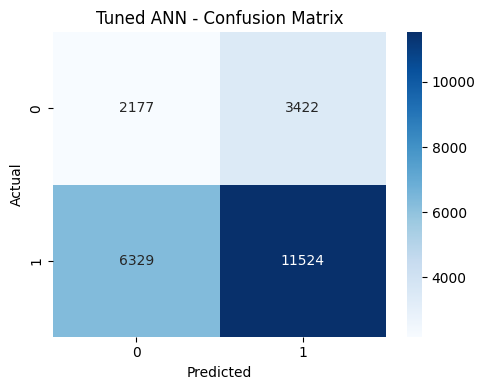

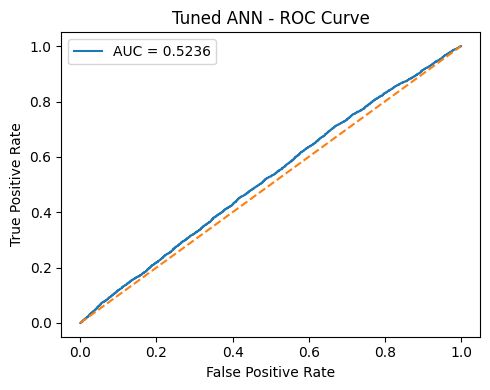

In [25]:
# ============================================================
# CELL 25: EVALUATE TUNED ANN
# ============================================================

ann_best = ann_search.best_estimator_

ann_best_acc, ann_best_auc = evaluate_model(
    ann_best, X_test_scaled, y_test, "Tuned ANN"
)

In [26]:
# ============================================================
# CELL 26: HYPERPARAMETER TUNING FOR RANDOM FOREST
# ============================================================

rf_param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [10, 20, None],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2],
    "max_features": ["sqrt"],
    "bootstrap": [True]
}

rf_search = RandomizedSearchCV(
    estimator=RandomForestClassifier(random_state=42, n_jobs=-1),
    param_distributions=rf_param_grid,
    n_iter=8,
    cv=3,
    scoring="roc_auc",
    verbose=1,
    random_state=42,
    n_jobs=-1
)

rf_search.fit(X_train_smote, y_train_smote)

print("Best Parameters:", rf_search.best_params_)
print("Best CV ROC-AUC:", rf_search.best_score_)

Fitting 3 folds for each of 8 candidates, totalling 24 fits
Best Parameters: {'n_estimators': 300, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': None, 'bootstrap': True}
Best CV ROC-AUC: 0.9134327457418379



Tuned Random Forest
Accuracy: 0.8152
ROC-AUC : 0.7083

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.25      0.39      5599
           1       0.81      0.99      0.89     17853

    accuracy                           0.82     23452
   macro avg       0.87      0.62      0.64     23452
weighted avg       0.84      0.82      0.77     23452

Confusion Matrix:
[[ 1379  4220]
 [  114 17739]]


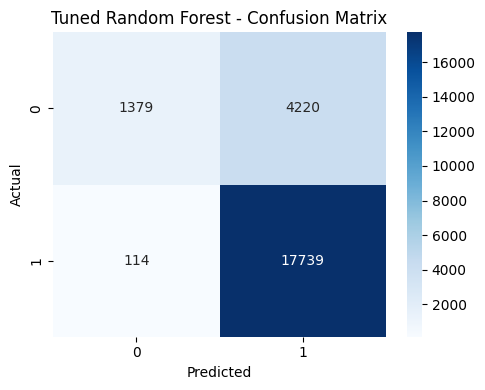

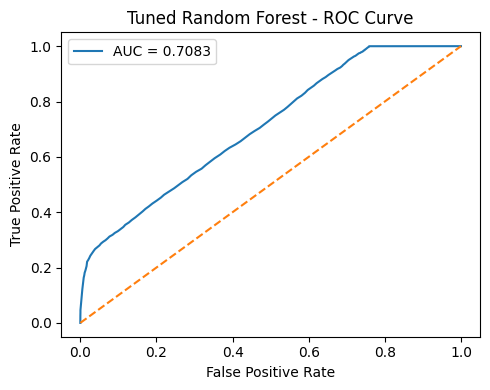

In [27]:
# ============================================================
# CELL 27: EVALUATE TUNED RANDOM FOREST
# ============================================================

rf_best = rf_search.best_estimator_

rf_best_acc, rf_best_auc = evaluate_model(
    rf_best, X_test_scaled, y_test, "Tuned Random Forest"
)

In [28]:
# ============================================================
# CELL 28: FINAL MODEL COMPARISON TABLE
# ============================================================

comparison_df = pd.DataFrame({
    "Model": [
        "RF Before SMOTE",
        "RF After SMOTE",
        "Tuned Random Forest",
        "Baseline XGBoost",
        "Tuned XGBoost",
        "Baseline ANN",
        "Tuned ANN"
    ],
    "Accuracy": [
        rf_before_acc,
        rf_after_acc,
        rf_best_acc,
        xgb_acc,
        xgb_best_acc,
        ann_acc,
        ann_best_acc
    ],
    "ROC-AUC": [
        rf_before_auc,
        rf_after_auc,
        rf_best_auc,
        xgb_auc,
        xgb_best_auc,
        ann_auc,
        ann_best_auc
    ]
})

display(comparison_df.sort_values(by="ROC-AUC", ascending=False))

,Model,Accuracy,ROC-AUC
0,RF Before SMOTE,0.818694,0.711563
1,RF After SMOTE,0.815197,0.708298
2,Tuned Random Forest,0.815197,0.708298
4,Tuned XGBoost,0.765351,0.607555
5,Baseline ANN,0.583873,0.536032
6,Tuned ANN,0.584215,0.523642
3,Baseline XGBoost,0.758315,0.514117


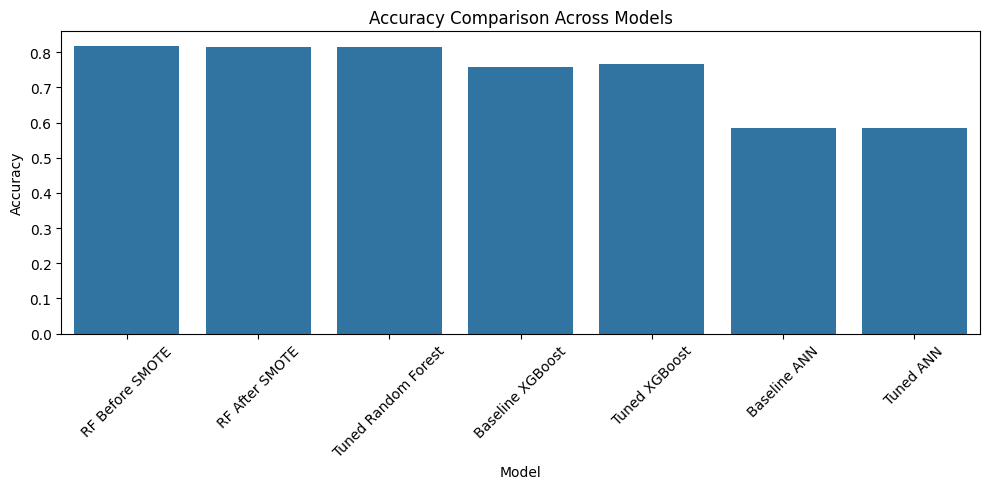

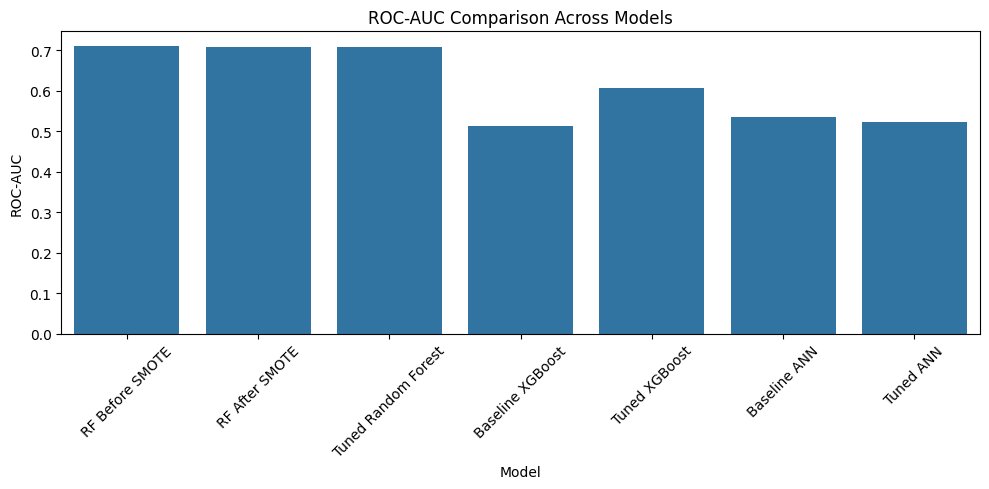

In [29]:
# ============================================================
# CELL 29: FINAL COMPARISON PLOTS
# ============================================================

plt.figure(figsize=(10, 5))
sns.barplot(x="Model", y="Accuracy", data=comparison_df)
plt.xticks(rotation=45)
plt.title("Accuracy Comparison Across Models")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
sns.barplot(x="Model", y="ROC-AUC", data=comparison_df)
plt.xticks(rotation=45)
plt.title("ROC-AUC Comparison Across Models")
plt.tight_layout()
plt.show()